In [1]:
import os 
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from utils import * 

# 1D cases analysis

In [2]:
log1d_paths = glob.glob('../logs/exp1d/*/*/*.csv')

In [3]:
log1d_df = load_accuracy_log(log1d_paths)

100%|██████████| 16568/16568 [01:29<00:00, 184.41it/s]


## select the best five result from test_l2

### trend on different residual type without coarsen

In [8]:
keep_best = []
not_enough = []
for model in ['fno1d', 'lno1d', 'ft1d', 'gt1d']:
    for dataset in ['cosine', 'burgers', 'lnabs']:
        for coarse_level in [0, 1, 2, 3, 4]:
            for residual in ['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4']:
                for resolution in [512, 1024, 2048, 4096, 8192]:
                    sub_df = log1d_df[(log1d_df.model == model) & (log1d_df.dataset == dataset) & (log1d_df.coarse_level == coarse_level) & (log1d_df.residual == residual) & (log1d_df.resolution == resolution)]
                    best_df = sub_df.sort_values(by='test_l2').iloc[:5]
                    if (best_df.shape[0] < 5) & (coarse_level == 4):
                        not_enough.append([model, dataset, coarse_level, residual, resolution, best_df.seed.tolist()])
                    
                    keep_best.append(best_df)

log1d_filt_df = pd.concat(keep_best)

In [9]:
not_enough

[['fno1d', 'cosine', 4, 'null', 512, []],
 ['fno1d', 'cosine', 4, 'diag', 512, []],
 ['fno1d', 'cosine', 4, 'ml1', 512, []],
 ['fno1d', 'lnabs', 4, 'null', 512, []],
 ['fno1d', 'lnabs', 4, 'diag', 512, [6]],
 ['lno1d', 'cosine', 4, 'null', 512, []],
 ['lno1d', 'cosine', 4, 'null', 1024, [2, 5]],
 ['lno1d', 'cosine', 4, 'null', 8192, [2, 5, 1, 4]],
 ['lno1d', 'cosine', 4, 'diag', 512, [6]],
 ['lno1d', 'lnabs', 4, 'null', 512, []],
 ['lno1d', 'lnabs', 4, 'diag', 512, [6]],
 ['ft1d', 'cosine', 4, 'null', 512, []],
 ['ft1d', 'cosine', 4, 'null', 2048, [4, 1, 7, 0]],
 ['ft1d', 'cosine', 4, 'diag', 512, []],
 ['ft1d', 'cosine', 4, 'diag', 1024, [7, 0, 5, 1]],
 ['ft1d', 'cosine', 4, 'diag', 4096, [0, 7, 1, 2]],
 ['ft1d', 'cosine', 4, 'diag', 8192, [4, 1, 0, 7]],
 ['ft1d', 'cosine', 4, 'ml1', 512, []],
 ['ft1d', 'cosine', 4, 'ml1', 8192, [7, 4, 0, 1]],
 ['ft1d', 'cosine', 4, 'ml2', 512, [4, 5, 6, 7]],
 ['ft1d', 'cosine', 4, 'ml2', 1024, [3, 1, 5, 4]],
 ['ft1d', 'lnabs', 4, 'null', 512, []],
 [

### Visualize single model with no coarsen and fix residual(null, diag, ml3)

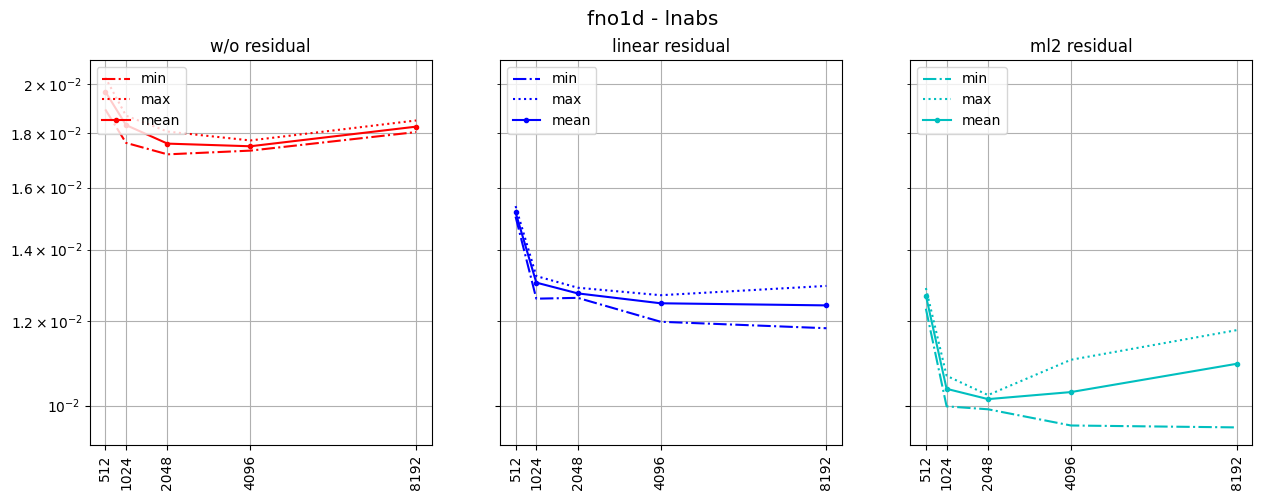

In [6]:
fig = vis1d_single_model_dataset_result(log1d_filt_df, model='fno1d', dataset='lnabs', ml='ml2')

### Visualize All type model with no coarsen and fix residual(null, diag, ml4)

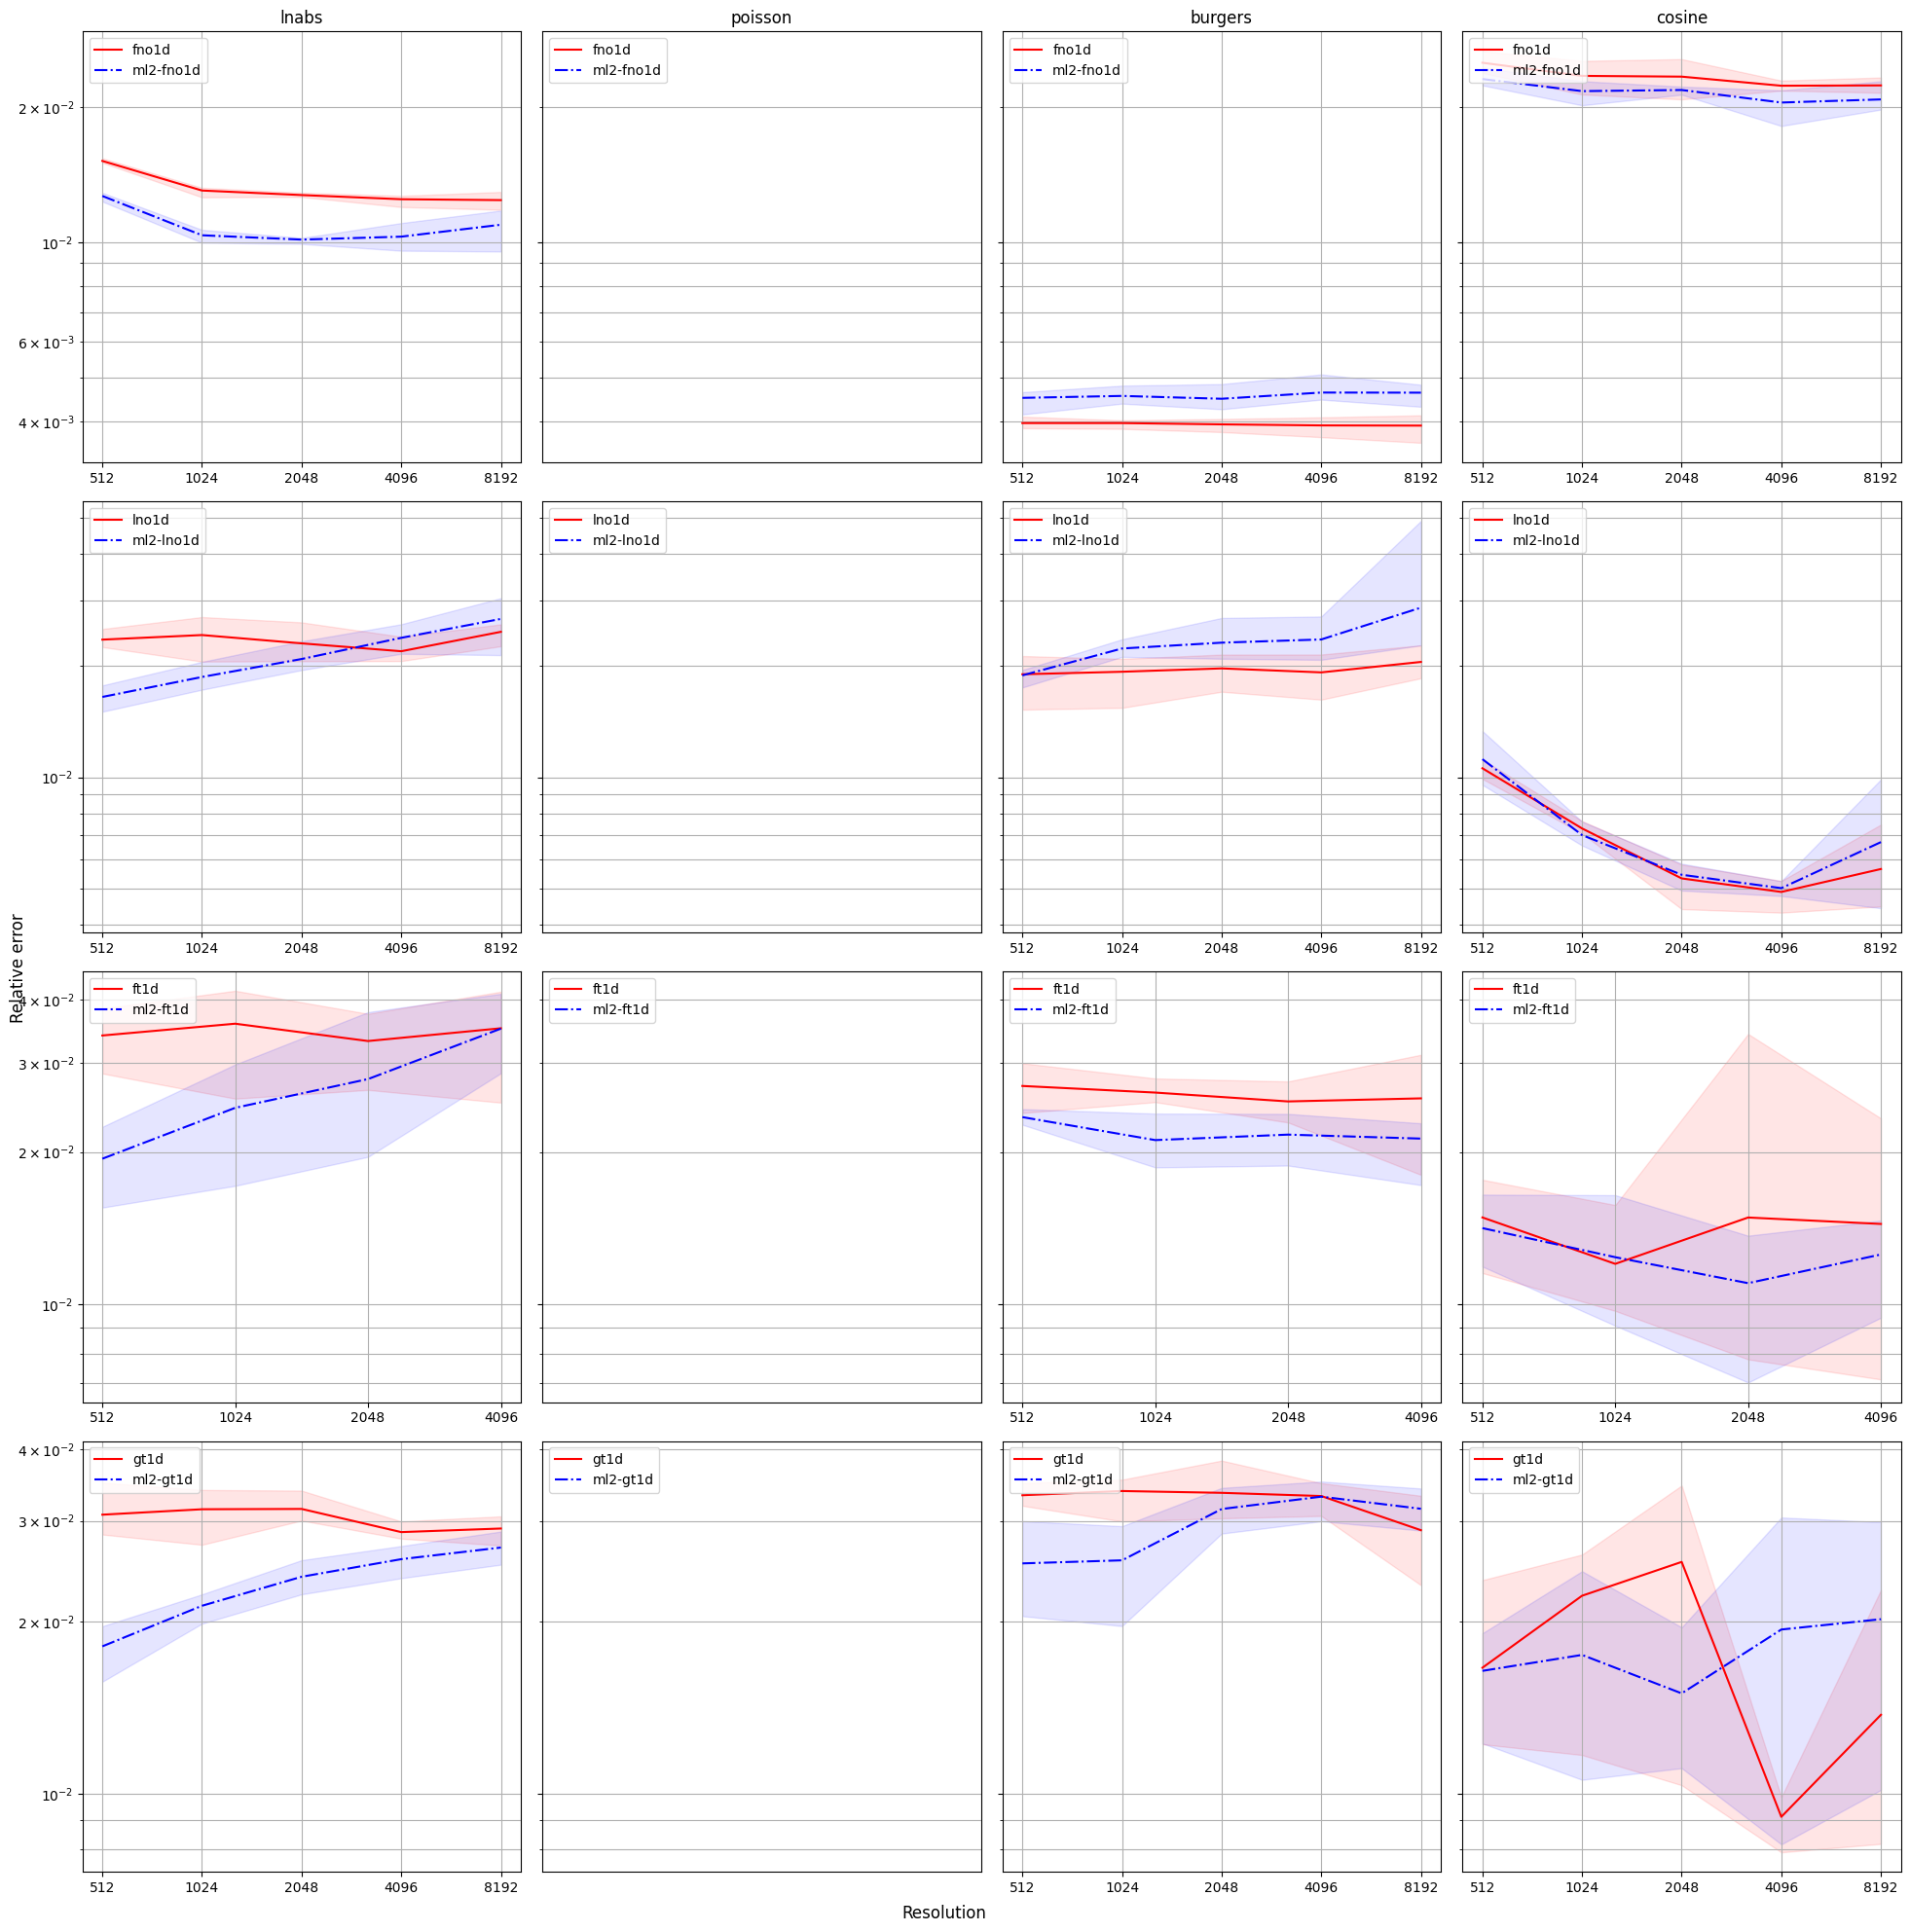

In [8]:
fig = vis1d_all_model_dataset_result(log1d_filt_df, ml='ml2')

### All type model with all type residuals and no coarsen with different resolutions

In [6]:
for dataset in ['lnabs', 'cosine', 'burgers', 'poisson']:

    print('='*80)
    print(dataset)
    print('='*80)

    for model in ['fno1d', 'lno1d', 'ft1d', 'gt1d']:
        clevel=0
        sub_df = log1d_df[(log1d_df.dataset == dataset) & (log1d_df.coarse_level == clevel) & (log1d_df.model == model)]
        l2_mean = sub_df.groupby(["model", "dataset", "coarse_level", "resolution", "residual"])['test_l2'].apply(np.mean).reset_index()
        l2_min = sub_df.groupby(["model", "dataset", "coarse_level", "resolution", "residual"])['test_l2'].apply(np.min).reset_index()
        l2_max = sub_df.groupby(["model", "dataset", "coarse_level", "resolution", "residual"])['test_l2'].apply(np.max).reset_index()
        
        print(l2_mean.pivot_table(values='test_l2', index=['model', 'residual'], columns=['resolution']))    

lnabs
resolution          512       1024      2048      4096      8192
model residual                                                  
fno1d diag      0.015386  0.013208  0.012797  0.012549  0.012411
      ml1       0.013371  0.011311  0.011242  0.011822  0.011778
      ml2       0.013033  0.010620  0.010339  0.010518  0.010942
      ml3       0.013904  0.010986  0.010433  0.010270  0.010639
      ml4       0.014054  0.011515  0.010158  0.010212  0.010095
      null      0.020216  0.018684  0.017848  0.017800  0.018248
resolution          512       1024      2048      4096      8192
model residual                                                  
lno1d diag      0.025838  0.026164  0.025350  0.024019  0.025472
      ml1       0.021599  0.023096  0.026913  0.025680  0.026941
      ml2       0.017407  0.020082  0.022633  0.026343  0.027885
      ml3       0.014044  0.016277  0.021695  0.025468  0.029791
      ml4       0.012441  0.013073  0.016169  0.020982  0.027013
      null      0.1

### All type model with all type residuals and no coarsen on 4096

In [7]:
import matplotlib.pyplot as plt 
import matplotlib as mpl

In [8]:
sub_df = log1d_df[(log1d_df.resolution == 4096) & (log1d_df.coarse_level == 0)]

In [9]:
sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['residual'])

residual           diag       ml1       ml2       ml3       ml4      null
dataset model                                                            
burgers fno1d  0.003917  0.004277  0.004635  0.004900  0.005563  0.005181
        ft1d   0.028048  0.027853  0.024619  0.020992  0.016660  0.029709
        gt1d   0.035649  0.035556  0.034614  0.026095  0.018566  0.034279
        lno1d  0.021258  0.023043  0.027052  0.027639  0.033687  0.049994
cosine  fno1d  0.022459  0.021396  0.020892  0.020277  0.020416  0.020575
        ft1d   0.014450  0.017853  0.013567  0.011273  0.010216  0.011660
        gt1d   0.019029  0.019325  0.019383  0.023399  0.019681  0.023811
        lno1d  0.005607  0.006451  0.005382  0.006178  0.006022  0.032585
lnabs   fno1d  0.012549  0.011822  0.010518  0.010270  0.010212  0.017800
        ft1d   0.038967  0.040001  0.038717  0.025184  0.021133  0.042803
        gt1d   0.030225  0.033777  0.028011  0.024328  0.018014  0.042644
        lno1d  0.024019  0.025680  0.026343  0.025468  0.020982  0.045222
poisson fno1d  0.006877  0.006658  0.007614  0.007893  0.008179  0.008898
        ft1d   0.036454  0.031472  0.031273  0.027463  0.024406  0.044579
        gt1d   0.022161  0.021342  0.017556  0.016401  0.016264  0.021104
        lno1d  0.010760  0.010390  0.011983  0.010318  0.010569  0.055838

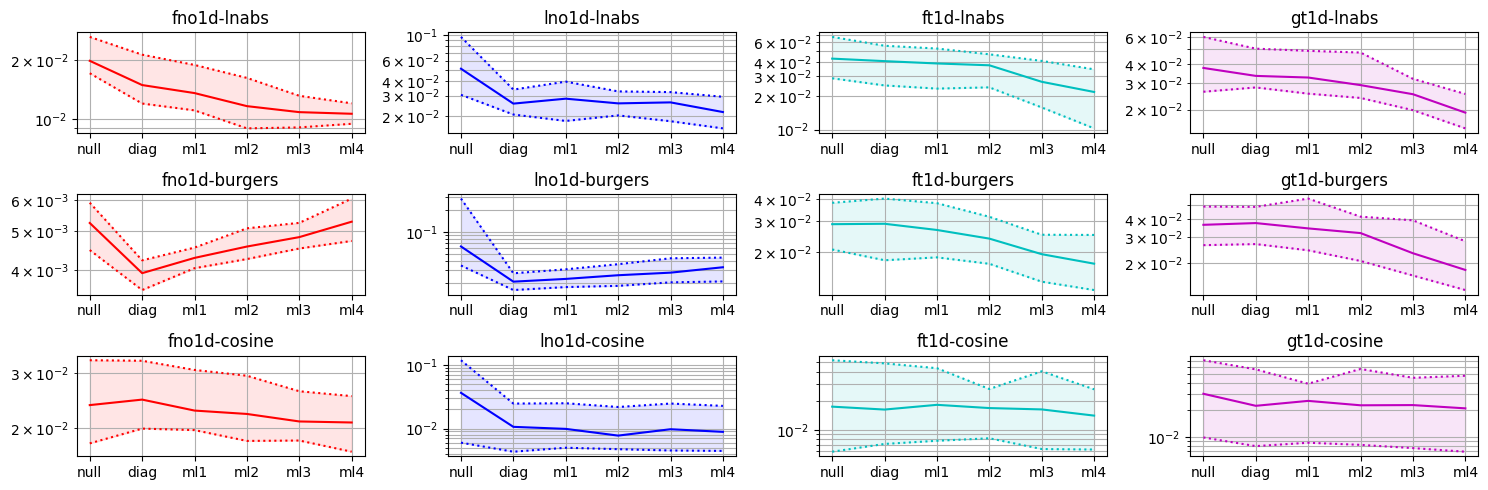

In [10]:
fig = vis_all_model_dataset_residual_trend_on_fix_resolution(log1d_df, resolution=4096)

### All type model with all coarsen and diag-ml4 on 4096

In [11]:
sub_df = log1d_df[(log1d_df.resolution == 4096) & (log1d_df.residual == 'diag')]
table_mean = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['coarse_level'], aggfunc=np.mean)
table_min = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['coarse_level'], aggfunc=np.min)
table_max = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['coarse_level'], aggfunc=np.max)

In [12]:
table_mean

coarse_level          0         1         2         3         4
dataset model                                                  
burgers fno1d  0.003917  0.003899  0.003904  0.003930  0.003959
        ft1d   0.028048  0.031160  0.031367  0.028068  0.026688
        gt1d   0.035649  0.037242  0.039935  0.036946  0.037698
        lno1d  0.021258  0.021288  0.020501  0.020627  0.021735
cosine  fno1d  0.022459  0.021973  0.024275  0.024471  0.030704
        ft1d   0.014450  0.012336  0.012272  0.016023  0.031295
        gt1d   0.019029  0.015512  0.024466  0.019114  0.033888
        lno1d  0.005607  0.006571  0.007859  0.011384  0.021787
lnabs   fno1d  0.012549  0.012632  0.013206  0.015331  0.020731
        ft1d   0.038967  0.035325  0.044808  0.042995  0.041495
        gt1d   0.030225  0.033222  0.031571  0.032428  0.038936
        lno1d  0.024019  0.024751  0.024439  0.025769  0.028802
poisson fno1d  0.006877  0.006941  0.007515  0.010093  0.015434
        ft1d   0.036454  0.043098  0.033120  0.035419  0.051151
        gt1d   0.022161  0.022212  0.020772  0.023189  0.025797
        lno1d  0.010760  0.011272  0.011489  0.013013  0.018088

### trend on same resolution with different coarsen level

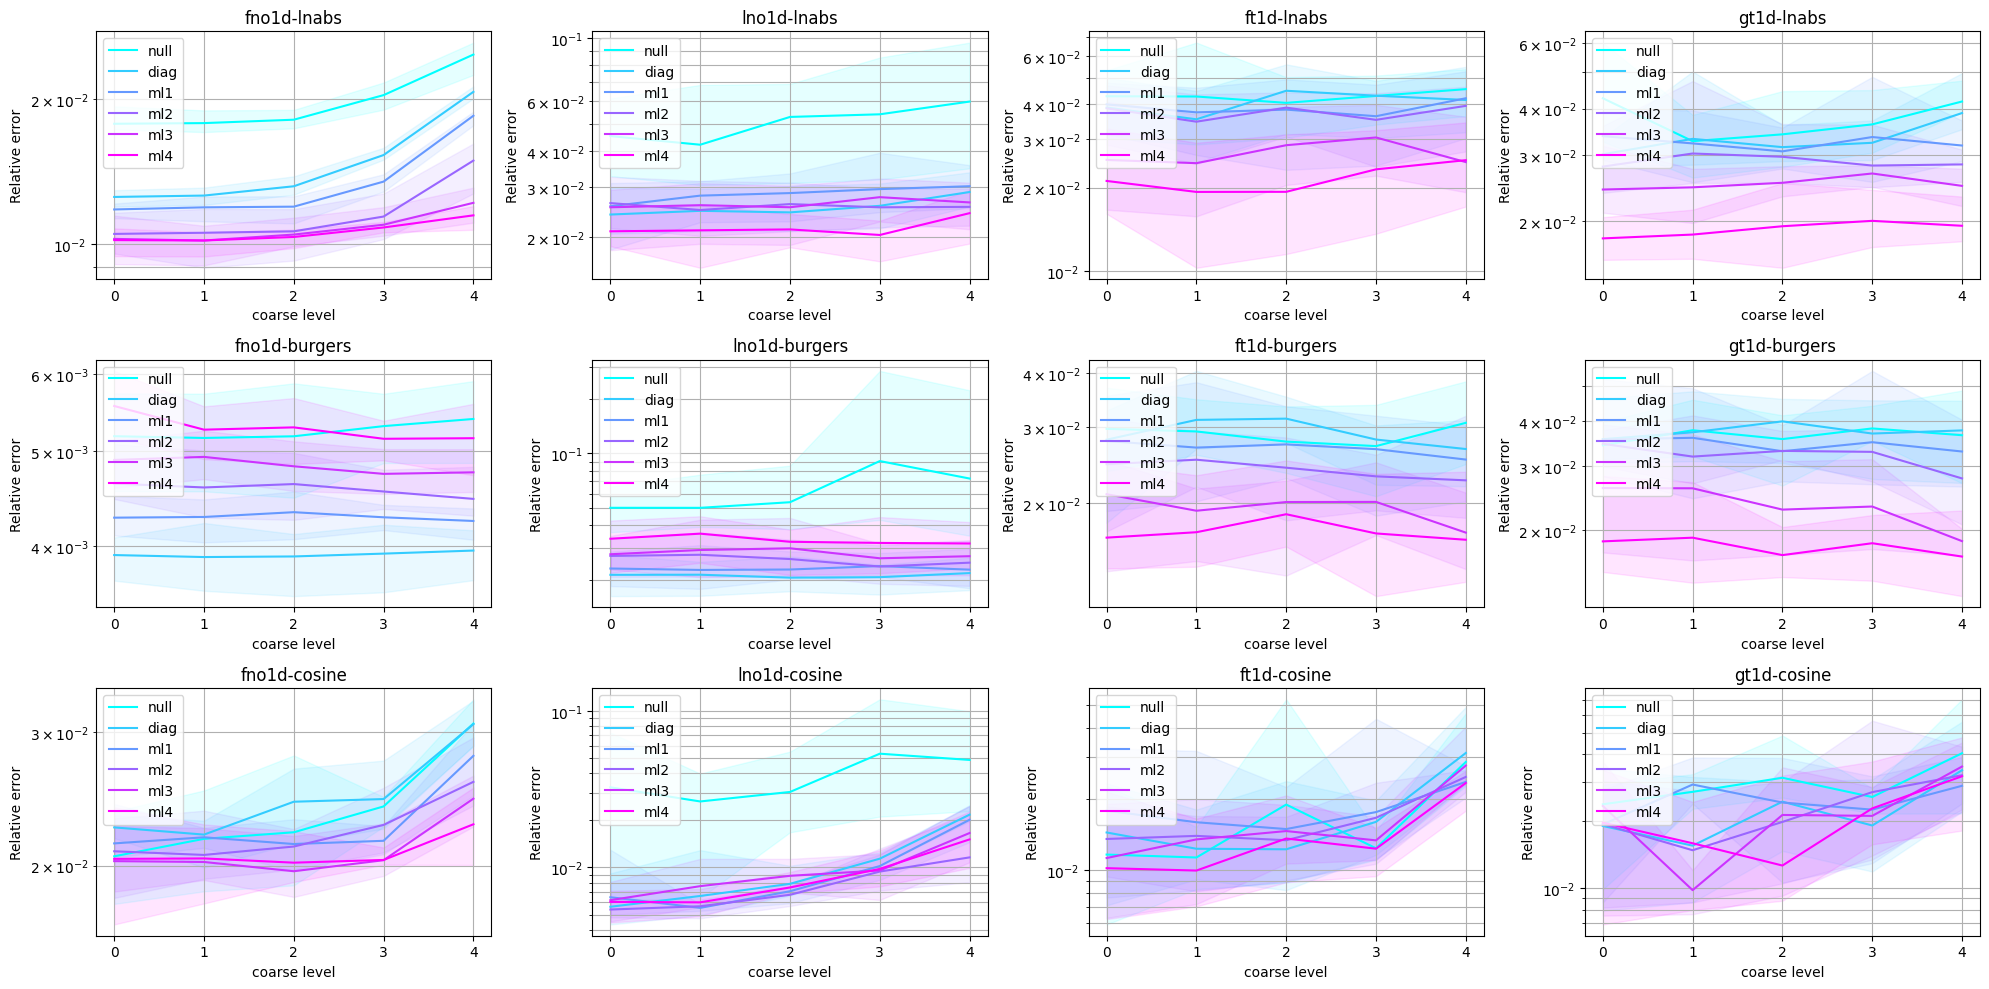

In [13]:
fig, axs = plt.subplots(3, 4, figsize=(20, 10))#, sharey='row')
sub_df = log1d_df[log1d_df.resolution == 4096]
colors = mpl.colormaps['cool']
coarse_levels = [0, 1, 2, 3, 4]
for m, model in enumerate(['fno1d', 'lno1d', 'ft1d', 'gt1d']):
    for d, dataset in enumerate(['lnabs', 'burgers', 'cosine']):
        subsub_df = sub_df[(sub_df.model == model) & (sub_df.dataset == dataset)]            
        table_mean = subsub_df.pivot_table(values='test_l2', index=['coarse_level'], columns=['residual'], aggfunc=np.mean)
        table_min = subsub_df.pivot_table(values='test_l2', index=['coarse_level'], columns=['residual'], aggfunc=np.min)
        table_max = subsub_df.pivot_table(values='test_l2', index=['coarse_level'], columns=['residual'], aggfunc=np.max)
        
        for r, residual in enumerate(['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4']):
            # axs[d][m].plot(table_mean.index, table_min[[residual]].values.reshape(-1), ":",color=colors(r*0.2))
            # axs[d][m].plot(table_mean.index, table_max[[residual]].values.reshape(-1), ":",color=colors(r*0.2))
            axs[d][m].plot(table_mean.index, table_mean[[residual]].values.reshape(-1), "-",color=colors(r*0.2), label=residual)
            axs[d][m].fill_between(table_mean.index, 
                                   table_min[[residual]].values.reshape(-1),
                                   table_max[[residual]].values.reshape(-1), color=colors(r*0.2), alpha=0.1)
            
        axs[d][m].set_xticks(coarse_levels)
        axs[d][m].set_xticklabels(coarse_levels)
        axs[d][m].set_title("{:}-{:}".format(model, dataset))
        axs[d][m].set_yscale('log')
        axs[d][m].grid(axis='both', which='both')
        axs[d][m].legend(loc='upper left')
        axs[d][m].set_xlabel('coarse level')
        axs[d][m].set_ylabel('Relative error')
        
fig.tight_layout()

In [72]:
table_mean

residual,diag,ml1,ml2,ml3,ml4,null
coarse_level,,,,,,
0,0.012549,0.011822,0.010518,0.010270,0.010212,0.017800
1,0.012632,0.011941,0.010576,0.010192,0.010193,0.017856
2,0.013206,0.011980,0.010648,0.010485,0.010366,0.018148
3,0.015331,0.013503,0.011428,0.010990,0.010847,0.020410
4,0.020731,0.018496,0.014929,0.012201,0.011493,0.024773


In [45]:
table_mean.loc[dataset, model].values

array([0.01219507, 0.01223168, 0.01247211, 0.0137514 , 0.01710402])

### trend on different residual type on different coarsen level

In [14]:
# model1d_df = log1d_agg_df[(log1d_agg_df.model == 'ft1d')]
# model1d_table = pd.pivot_table(model1d_df, values='test_l2', index=['resolution', 'residual'], columns=['dataset', 'coarse_level'])
# model1d_table = model1d_table.reindex(
#     pd.MultiIndex.from_product(
#         [model1d_table.index.levels[0], ['null','diag','ml1', 'ml2', 'ml3', 'ml4']]), axis=0)

In [15]:
# for model_nm in ['ft1d', 'gt1d', 'fno1d', 'lno1d']:
#     model1d_df = log1d_agg_df[(log1d_agg_df.model == model_nm)]
#     model1d_table = pd.pivot_table(model1d_df, values='test_l2', index=['resolution', 'residual'], columns=['dataset', 'coarse_level'])
#     model1d_table = model1d_table.reindex(
#         pd.MultiIndex.from_product(
#             [model1d_table.index.levels[0], ['null','diag','ml1', 'ml2', 'ml3', 'ml4']]), axis=0)

#     fig = plt.figure(figsize=(40, 10))
#     fig.suptitle(model_nm)
#     fig.subplots_adjust(top=0.95)
    
#     bmin = model1d_table['burgers'].min().min()
#     bmax = model1d_table['burgers'].max().max()
#     plt.subplot(1,4,1)
#     plt.title('burgers')
#     sns.heatmap(model1d_table['burgers'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=bmin, vmax=bmax)

#     pmin = model1d_table['poisson'].min().min()
#     pmax = model1d_table['poisson'].max().max()
#     plt.subplot(1,4,2)
#     plt.title('poisson')
#     sns.heatmap(model1d_table['poisson'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=pmin, vmax=pmax)

#     cmin = model1d_table['cosine'].min().min()
#     cmax = model1d_table['cosine'].max().max()
#     plt.subplot(1,4,3)
#     plt.title('cosine')
#     sns.heatmap(model1d_table['cosine'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=cmin, vmax=cmax)

#     lmin = model1d_table['lnabs'].min().min()
#     lmax = model1d_table['lnabs'].max().max()
#     plt.subplot(1,4,4)
#     plt.title('lnabs')
#     sns.heatmap(model1d_table['lnabs'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=lmin, vmax=lmax)

In [ ]:
# 2D cases analysis

In [10]:
log2d_paths = glob.glob('../logs/exp2d/*/*/*.csv')
log2d_df = load_accuracy_log(log2d_paths)

  0%|          | 0/4792 [00:00<?, ?it/s]

100%|██████████| 4792/4792 [00:19<00:00, 242.12it/s]


In [11]:
log2d_df.resolution.unique()

array([211, 106, 421,  85, 141])

In [12]:
log2d_df.model.unique()

array(['fno2d', 'lno2d', 'gt2d', 'ft2d'], dtype=object)

In [15]:
keep_best = []
not_enough = []
for model in ['fno2d', 'lno2d', 'ft2d', 'gt2d']:
    for dataset in ['darcy', 'invdist']:
        for coarse_level in [0, 1, 2, 3, 4]:
            for residual in ['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4']:
                for resolution in [85, 106, 141, 211, 421]:
                    sub_df = log2d_df[(log2d_df.model == model) & (log2d_df.dataset == dataset) & (log2d_df.coarse_level == coarse_level) & (log2d_df.residual == residual) & (log2d_df.resolution == resolution)]
                    best_df = sub_df.sort_values(by='test_l2').iloc[:5]
                    if (best_df.shape[0] < 5) & (coarse_level == 1):
                        not_enough.append([model, dataset, coarse_level, residual, resolution, best_df.seed.tolist()])
                    
                    keep_best.append(best_df)

log2d_filt_df = pd.concat(keep_best)

In [16]:
len(not_enough)

120

In [17]:
not_enough

[['fno2d', 'darcy', 1, 'null', 211, [1, 3, 2]],
 ['fno2d', 'darcy', 1, 'null', 421, [1, 2, 3]],
 ['fno2d', 'darcy', 1, 'diag', 211, [3, 1, 2]],
 ['fno2d', 'darcy', 1, 'diag', 421, [1, 3, 2]],
 ['fno2d', 'darcy', 1, 'ml1', 211, [2, 3, 1]],
 ['fno2d', 'darcy', 1, 'ml1', 421, [2, 3, 1]],
 ['fno2d', 'darcy', 1, 'ml2', 211, [2, 3, 1]],
 ['fno2d', 'darcy', 1, 'ml2', 421, []],
 ['fno2d', 'darcy', 1, 'ml3', 211, [2, 3, 1]],
 ['fno2d', 'darcy', 1, 'ml3', 421, []],
 ['fno2d', 'darcy', 1, 'ml4', 211, [3]],
 ['fno2d', 'darcy', 1, 'ml4', 421, []],
 ['fno2d', 'invdist', 1, 'null', 211, []],
 ['fno2d', 'invdist', 1, 'null', 421, [1, 3, 2]],
 ['fno2d', 'invdist', 1, 'diag', 211, []],
 ['fno2d', 'invdist', 1, 'diag', 421, [2, 3, 1]],
 ['fno2d', 'invdist', 1, 'ml1', 211, []],
 ['fno2d', 'invdist', 1, 'ml1', 421, []],
 ['fno2d', 'invdist', 1, 'ml2', 211, []],
 ['fno2d', 'invdist', 1, 'ml2', 421, []],
 ['fno2d', 'invdist', 1, 'ml3', 211, []],
 ['fno2d', 'invdist', 1, 'ml3', 421, []],
 ['fno2d', 'invdist',

In [ ]:
log2d_agg_df = log2d_df.groupby(['model', 'dataset', 'coarse_level','resolution','residual'])['test_l2'].apply(np.min).reset_index()

### trend on different residual type without coarsen

In [ ]:
# for model_nm in ['fno2d', 'lno2d', 'ft2d', 'gt2d']:
#     res2d_df = log2d_agg_df[(log2d_agg_df.model == model_nm) & (log2d_agg_df.coarse_level == 0)]# & (log_df.dataset != 'burgers')]
#     g = sns.catplot(data=res2d_df, x='residual', y='test_l2', row='dataset', col='resolution', kind='point', order=['null','diag','ml1', 'ml2', 'ml3', 'ml4'], hue='dataset')
#     g.set(yscale='log')
#     g.fig.subplots_adjust(top=0.92)
#     g.fig.suptitle(model_nm)

### trend on same resolution with different coarsen level

In [ ]:
# for model_nm in ['ft2d', 'gt2d', 'fno2d', 'lno2d']:
#     sub_df = log2d_agg_df[(log2d_agg_df.model == model_nm) & (log2d_agg_df.resolution == 85)]
#     g = sns.catplot(data=sub_df, x='coarse_level', y='test_l2', col='residual', row='dataset', kind='point', col_order=['null','diag','ml1', 'ml2', 'ml3', 'ml4'], hue='dataset')
#     g.set(yscale='log')
#     g.fig.subplots_adjust(top=0.92)
#     g.fig.suptitle(model_nm)

In [ ]:
# for model_nm in ['ft2d', 'gt2d', 'fno2d', 'lno2d']:
#     model2d_df = log2d_agg_df[(log2d_agg_df.model == model_nm)]
#     model2d_table = pd.pivot_table(model2d_df, values='test_l2', index=['resolution', 'residual'], columns=['dataset', 'coarse_level'])
#     model2d_table = model2d_table.reindex(
#         pd.MultiIndex.from_product(
#             [model2d_table.index.levels[0], ['null','diag','ml1', 'ml2', 'ml3', 'ml4']]), axis=0)

#     fig = plt.figure(figsize=(20, 10))
#     fig.suptitle(model_nm)
#     fig.subplots_adjust(top=0.95)

#     plt.subplot(1,2,1)
#     plt.title('darcy')
#     sns.heatmap(model2d_table['darcy'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=0, vmax=0.1)
#     plt.subplot(1,2,2)
#     plt.title('invdist')
#     sns.heatmap(model2d_table['invdist'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=0, vmax=0.1)